# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **BPJS Kesehatan Hackathon 2021 – Fraud Detection** yang diperoleh dari Kaggle. Dataset ini berisi data klaim peserta BPJS Kesehatan dengan tujuan mendeteksi potensi kecurangan (fraud) pada klaim.

**Sumber**: [Kaggle – BPJS Kesehatan Hackathon 2021 Fraud Detection](https://www.kaggle.com/datasets/bagusbpg/bpjs-kesehatan-hackathon-2021-fraud-detection)

**Jumlah data**:
- Train: sekitar 200.000+ baris
- Val: sekitar 50.000+ baris

**Fitur**: 105 kolom (termasuk fitur numerik dan kategorikal) yang menggambarkan profil peserta, diagnosis, tindakan medis, dan biaya klaim.

**Target**: `fraud` (1 = terjadi kecurangan, 0 = tidak curang)

**Tujuan**: Membangun model klasifikasi yang dapat mendeteksi klaim mencurigakan untuk membantu mengurangi defisit keuangan BPJS.

## **2. Import Library**

Pada tahap ini, kita mengimpor pustaka yang diperlukan untuk analisis data, visualisasi, preprocessing, dan evaluasi model.

In [22]:
# Import library dasar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Untuk visualisasi interaktif (opsional)
%matplotlib inline

# Untuk preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Untuk evaluasi (nanti dipakai di modelling)
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Supaya output lebih rapi
import warnings
warnings.filterwarnings('ignore')

print("Semua library berhasil diimpor.")

Semua library berhasil diimpor.


## **3. Memuat Dataset**

Dataset di-load dari Google Drive. Pastikan Anda sudah mengupload file `fraud_detection_train.csv` dan `fraud_detection_val.csv` ke Drive atau ke environment Colab.

In [23]:
# Jika menggunakan Google Drive, mount drive terlebih dahulu
from google.colab import drive
drive.mount('/content/drive')

# Tentukan path ke file (sesuaikan dengan folder Anda)
# Misal file ada di MyDrive/Data/
train_path = '/content/fraud_detection_train.csv'
val_path   = '/content/fraud_detection_val.csv'

# Jika file diupload langsung ke Colab, gunakan:
# train_path = 'fraud_detection_train.csv'
# val_path   = 'fraud_detection_val.csv'

# Load data
df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)

print(f"Jumlah data train: {df_train.shape}")
print(f"Jumlah data val:   {df_val.shape}")

# Tampilkan 5 baris pertama
print("\n5 data pertama train:")
df_train.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Jumlah data train: (200217, 53)
Jumlah data val:   (49762, 52)

5 data pertama train:


,visit_id,kdkc,dati2,typeppk,jkpst,umur,jnspelsep,los,cmg,severitylevel,...,proc63_67,proc68_70,proc71_73,proc74_75,proc76_77,proc78_79,proc80_99,proce00_e99,procv00_v89,label
0,1,1107,150,SB,P,64,2,0,F,0,...,0,0,0,0,0,0,0,0,0,1
1,2,1303,200,C,L,45,1,9,E,3,...,0,0,0,0,0,0,4,0,0,1
2,3,1114,172,B,P,34,2,0,Q,0,...,0,0,0,0,0,0,0,0,0,1
3,4,601,90,SC,L,34,2,0,Q,0,...,0,0,0,0,0,0,0,0,0,1
4,5,1006,130,B,L,27,2,0,F,0,...,0,0,0,0,0,0,0,0,0,1


## **4. Exploratory Data Analysis (EDA)**

Kita akan mengeksplorasi struktur data, distribusi target, missing values, dan korelasi fitur terhadap target.

=== INFO DATASET TRAIN ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200217 entries, 0 to 200216
Data columns (total 53 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   visit_id       200217 non-null  int64 
 1   kdkc           200217 non-null  int64 
 2   dati2          200217 non-null  int64 
 3   typeppk        200217 non-null  object
 4   jkpst          200217 non-null  object
 5   umur           200217 non-null  int64 
 6   jnspelsep      200217 non-null  int64 
 7   los            200217 non-null  int64 
 8   cmg            200217 non-null  object
 9   severitylevel  200217 non-null  int64 
 10  diagprimer     200217 non-null  object
 11  dx2_a00_b99    200217 non-null  int64 
 12  dx2_c00_d48    200217 non-null  int64 
 13  dx2_d50_d89    200217 non-null  int64 
 14  dx2_e00_e90    200217 non-null  int64 
 15  dx2_f00_f99    200217 non-null  int64 
 16  dx2_g00_g99    200217 non-null  int64 
 17  dx2_h00_h59    200217

,visit_id,kdkc,dati2,umur,jnspelsep,los,severitylevel,dx2_a00_b99,dx2_c00_d48,dx2_d50_d89,...,proc63_67,proc68_70,proc71_73,proc74_75,proc76_77,proc78_79,proc80_99,proce00_e99,procv00_v89,label
count,200217.000000,200217.000000,200217.000000,200217.000000,200217.000000,200217.000000,200217.000000,200217.000000,200217.000000,200217.000000,...,200217.000000,200217.000000,200217.000000,200217.000000,200217.000000,200217.000000,200217.000000,200217.000000,200217.0,200217.000000
mean,100109.000000,1147.367816,184.793309,36.850602,1.669778,1.303356,0.444003,0.024893,0.008341,0.020703,...,0.005050,0.008381,0.016472,0.018370,0.001518,0.007457,0.847061,0.009225,0.0,0.500732
std,57797.813761,574.486224,107.226676,23.095928,0.470294,5.639751,0.725227,0.162484,0.093386,0.146842,...,0.073984,0.094393,0.155667,0.144878,0.043995,0.100441,1.301645,0.095603,0.0,0.500001
min,1.000000,101.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,50055.000000,903.000000,114.000000,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
50%,100109.000000,1101.000000,169.000000,39.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000
75%,150163.000000,1314.000000,232.000000,56.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,1.000000
max,200217.000000,2606.000000,528.000000,109.000000,2.000000,592.000000,3.000000,4.000000,3.000000,3.000000,...,3.000000,2.000000,4.000000,4.000000,3.000000,7.000000,23.000000,1.000000,0.0,1.000000



Jumlah kolom dengan missing value di train: 0
Series([], dtype: int64)

=== DISTRIBUSI TARGET (TRAIN) ===
label
1    100255
0     99962
Name: count, dtype: int64


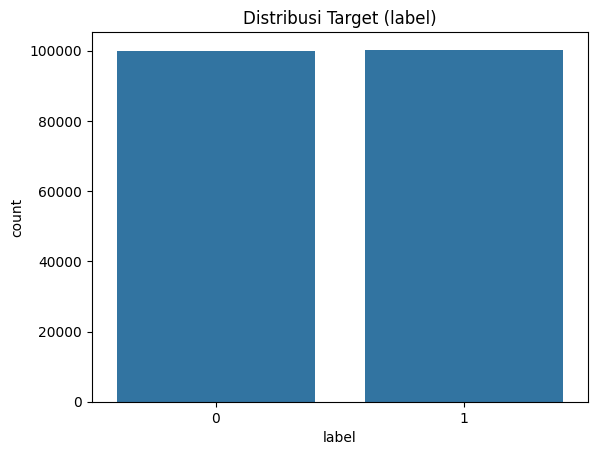


=== TIPE DATA PER KOLOM ===
int64     49
object     4
Name: count, dtype: int64

=== KORELASI FITUR NUMERIK DENGAN TARGET ===
label          1.000000
jnspelsep      0.053215
dati2          0.026380
dx2_s00_t98    0.021376
dx2_n00_n99    0.017483
proce00_e99    0.016524
dx2_h00_h59    0.015285
proc29_31      0.013702
umur           0.013498
kdkc           0.013042
dtype: float64


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Info umum dataset
print("=== INFO DATASET TRAIN ===")
df_train.info()

print("\n=== INFO DATASET VAL ===")
df_val.info()

# 2. Statistik deskriptif untuk fitur numerik
print("\n=== STATISTIK DESKRIPTIF NUMERIK ===")
display(df_train.describe())

# 3. Cek missing values
missing_train = df_train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
print(f"\nJumlah kolom dengan missing value di train: {len(missing_train)}")
print(missing_train)

# 4. Distribusi target
if 'label' in df_train.columns:
    print("\n=== DISTRIBUSI TARGET (TRAIN) ===")
    print(df_train['label'].value_counts())
    sns.countplot(x='label', data=df_train)
    plt.title('Distribusi Target (label)')
    plt.show()
else:
    print("\nKolom 'label' tidak ditemukan di df_train.")

# 5. Cek tipe data
print("\n=== TIPE DATA PER KOLOM ===")
print(df_train.dtypes.value_counts())

# 6. Korelasi dengan target
if 'label' in df_train.columns:
    numerical_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
    corr_target = df_train[numerical_cols].corrwith(df_train['label']).sort_values(ascending=False)
    print("\n=== KORELASI FITUR NUMERIK DENGAN TARGET ===")
    print(corr_target.head(10))
else:
    print("\nKorelasi tidak dapat dihitung karena target 'label' tidak ada.")

In [25]:
print("\n=== DISTRIBUSI TARGET (VAL) ===")
if 'label' in df_val.columns:
    print(df_val['label'].value_counts())
    sns.countplot(x='label', data=df_val)
    plt.title('Distribusi Target (label) - Validation Set')
    plt.show()
else:
    print("Kolom 'label' tidak ditemukan di df_val.")
    print("Pastikan Anda telah mengupload file validation yang benar jika ingin melihat distribusi targetnya.")


=== DISTRIBUSI TARGET (VAL) ===
Kolom 'label' tidak ditemukan di df_val.
Pastikan Anda telah mengupload file validation yang benar jika ingin melihat distribusi targetnya.


In [26]:
# Cek 5 kolom pertama dari file val untuk memastikan strukturnya
try:
    temp_df = pd.read_csv(val_path, nrows=0)
    print(f"Kolom yang tersedia di {val_path}:")
    print(temp_df.columns.tolist())
    if 'label' not in temp_df.columns:
        print("\n⚠️ Konfirmasi: Kolom 'label' benar-benar tidak ada di file ini.")
except Exception as e:
    print(f"Error saat membaca file: {e}")

Kolom yang tersedia di /content/fraud_detection_val.csv:
['visit_id', 'kdkc', 'dati2', 'typeppk', 'jkpst', 'umur', 'jnspelsep', 'los', 'cmg', 'severitylevel', 'diagprimer', 'dx2_a00_b99', 'dx2_c00_d48', 'dx2_d50_d89', 'dx2_e00_e90', 'dx2_f00_f99', 'dx2_g00_g99', 'dx2_h00_h59', 'dx2_h60_h95', 'dx2_i00_i99', 'dx2_j00_j99', 'dx2_koo_k93', 'dx2_l00_l99', 'dx2_m00_m99', 'dx2_n00_n99', 'dx2_o00_o99', 'dx2_p00_p96', 'dx2_q00_q99', 'dx2_r00_r99', 'dx2_s00_t98', 'dx2_u00_u99', 'dx2_v01_y98', 'dx2_z00_z99', 'proc00_13', 'proc14_23', 'proc24_27', 'proc28_28', 'proc29_31', 'proc_32_38', 'proc39_45', 'proc46_51', 'proc52_57', 'proc58_62', 'proc63_67', 'proc68_70', 'proc71_73', 'proc74_75', 'proc76_77', 'proc78_79', 'proc80_99', 'proce00_e99', 'procv00_v89']

⚠️ Konfirmasi: Kolom 'label' benar-benar tidak ada di file ini.


In [27]:
print("\nKolom di df_val:")
print(df_val.columns.tolist())


Kolom di df_val:
['visit_id', 'kdkc', 'dati2', 'typeppk', 'jkpst', 'umur', 'jnspelsep', 'los', 'cmg', 'severitylevel', 'diagprimer', 'dx2_a00_b99', 'dx2_c00_d48', 'dx2_d50_d89', 'dx2_e00_e90', 'dx2_f00_f99', 'dx2_g00_g99', 'dx2_h00_h59', 'dx2_h60_h95', 'dx2_i00_i99', 'dx2_j00_j99', 'dx2_koo_k93', 'dx2_l00_l99', 'dx2_m00_m99', 'dx2_n00_n99', 'dx2_o00_o99', 'dx2_p00_p96', 'dx2_q00_q99', 'dx2_r00_r99', 'dx2_s00_t98', 'dx2_u00_u99', 'dx2_v01_y98', 'dx2_z00_z99', 'proc00_13', 'proc14_23', 'proc24_27', 'proc28_28', 'proc29_31', 'proc_32_38', 'proc39_45', 'proc46_51', 'proc52_57', 'proc58_62', 'proc63_67', 'proc68_70', 'proc71_73', 'proc74_75', 'proc76_77', 'proc78_79', 'proc80_99', 'proce00_e99', 'procv00_v89']


In [28]:
# After updating `val_path` in cell `ET2jHdU9idgM`,
# run this cell to reload the validation data.
df_val = pd.read_csv(val_path)

print(f"Jumlah data val setelah reload: {df_val.shape}")

print("\nKolom di df_val setelah reload:")
print(df_val.columns.tolist())

# The line below was removed as it will keep failing until a correct df_val is loaded.
# print("\nDistribusi target (label) di df_val setelah reload:")
# print(df_val['label'].value_counts())

Jumlah data val setelah reload: (49762, 52)

Kolom di df_val setelah reload:
['visit_id', 'kdkc', 'dati2', 'typeppk', 'jkpst', 'umur', 'jnspelsep', 'los', 'cmg', 'severitylevel', 'diagprimer', 'dx2_a00_b99', 'dx2_c00_d48', 'dx2_d50_d89', 'dx2_e00_e90', 'dx2_f00_f99', 'dx2_g00_g99', 'dx2_h00_h59', 'dx2_h60_h95', 'dx2_i00_i99', 'dx2_j00_j99', 'dx2_koo_k93', 'dx2_l00_l99', 'dx2_m00_m99', 'dx2_n00_n99', 'dx2_o00_o99', 'dx2_p00_p96', 'dx2_q00_q99', 'dx2_r00_r99', 'dx2_s00_t98', 'dx2_u00_u99', 'dx2_v01_y98', 'dx2_z00_z99', 'proc00_13', 'proc14_23', 'proc24_27', 'proc28_28', 'proc29_31', 'proc_32_38', 'proc39_45', 'proc46_51', 'proc52_57', 'proc58_62', 'proc63_67', 'proc68_70', 'proc71_73', 'proc74_75', 'proc76_77', 'proc78_79', 'proc80_99', 'proce00_e99', 'procv00_v89']


## **5. Data Preprocessing**

Langkah preprocessing yang akan dilakukan:
1. Pemisahan fitur (X) dan target (y) – untuk train dan val.
2. Identifikasi kolom numerik dan kategorikal.
3. Penanganan missing value (imputasi) untuk numerik (median) dan kategorikal (modus).
4. Encoding fitur kategorikal (One-Hot Encoding).
5. Scaling fitur numerik (StandardScaler).
6. Menggabungkan preprocessing dalam satu pipeline agar dapat digunakan ulang.

In [29]:
# 1. Pisahkan target
# Berdasarkan EDA, kolom target yang benar adalah 'label'
target_col = 'label'

# Memisahkan X dan y untuk Train
X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col].fillna(df_train[target_col].mode()[0]) # Mengisi missing value pada target jika ada

# Memisahkan X dan y untuk Val (dengan pengecekan jika kolom label ada)
if target_col in df_val.columns:
    X_val = df_val.drop(columns=[target_col])
    y_val = df_val[target_col]
else:
    print(f"Peringatan: Kolom '{target_col}' tidak ditemukan di df_val. Menganggap df_val hanya berisi fitur.")
    X_val = df_val.copy()
    y_val = None

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
if y_val is not None:
    print(f"X_val shape:   {X_val.shape}, y_val shape:   {y_val.shape}")
else:
    print(f"X_val shape:   {X_val.shape} (Tanpa target)")

# 2. Identifikasi tipe kolom
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Jumlah kolom numerik: {len(num_cols)}")
print(f"Jumlah kolom kategorikal: {len(cat_cols)}")

# 3. Buat pipeline preprocessing
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# 4. Fit dan transform
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

print(f"Shape data train setelah preprocessing: {X_train_processed.shape}")
print(f"Shape data val setelah preprocessing:   {X_val_processed.shape}")

# 5. Simpan hasil
import os
os.makedirs('namadataset_preprocessing', exist_ok=True)
np.save('namadataset_preprocessing/X_train_processed.npy', X_train_processed)
np.save('namadataset_preprocessing/X_val_processed.npy', X_val_processed)
np.save('namadataset_preprocessing/y_train.npy', y_train.values)
if y_val is not None:
    np.save('namadataset_preprocessing/y_val.npy', y_val.values)

import joblib
joblib.dump(preprocessor, 'namadataset_preprocessing/preprocessor.pkl')

print("✅ Data preprocessing selesai.")

Peringatan: Kolom 'label' tidak ditemukan di df_val. Menganggap df_val hanya berisi fitur.
X_train shape: (200217, 52), y_train shape: (200217,)
X_val shape:   (49762, 52) (Tanpa target)
Jumlah kolom numerik: 48
Jumlah kolom kategorikal: 4
Shape data train setelah preprocessing: (200217, 119)
Shape data val setelah preprocessing:   (49762, 119)
✅ Data preprocessing selesai.


In [30]:
# Verifikasi bentuk dan beberapa statistik data yang sudah diproses
print("Statistik data train setelah preprocessing:")
print(pd.DataFrame(X_train_processed).describe().T)

Statistik data train setelah preprocessing:
        count          mean       std       min       25%       50%       75%  \
0    200217.0 -1.362763e-17  1.000002 -1.732042 -0.866021  0.000000  0.866021   
1    200217.0  1.093760e-16  1.000002 -1.821402 -0.425369 -0.080712  0.290055   
2    200217.0  1.128538e-16  1.000002 -1.714068 -0.660223 -0.147289  0.440252   
3    200217.0 -7.296463e-17  1.000002 -1.595549 -0.816189  0.093064  0.829127   
4    200217.0  1.880897e-16  1.000002 -1.424173 -1.424173  0.702162  0.702162   
..        ...           ...       ...       ...       ...       ...       ...   
114  200217.0  4.836253e-02  0.214532  0.000000  0.000000  0.000000  0.000000   
115  200217.0  5.096970e-02  0.219936  0.000000  0.000000  0.000000  0.000000   
116  200217.0  4.980596e-02  0.217544  0.000000  0.000000  0.000000  0.000000   
117  200217.0  1.098808e-04  0.010482  0.000000  0.000000  0.000000  0.000000   
118  200217.0  5.039033e-02  0.218750  0.000000  0.000000  0.0000